In [1]:
import pandas as pd

DATA_PATH = "./fake_or_real_news.csv"
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(6335, 4)


,id,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [2]:
df['content'] = df['title'] + " " + df['text']
df = df[['content', 'label']]
df.head()

,content,label
0,You Can Smell Hillary’s Fear Daniel Greenfield...,FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,FAKE
2,Kerry to go to Paris in gesture of sympathy U....,REAL
3,Bernie supporters on Twitter erupt in anger ag...,FAKE
4,The Battle of New York: Why This Primary Matte...,REAL


In [3]:
import re
import string
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df['content'] = df['content'].apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asmat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asmat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])  # FAKE=0, REAL=1

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

MAX_WORDS = 30000
MAX_LEN = 400   # news articles are long

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['content'])

sequences = tokenizer.texts_to_sequences(df['content'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

class Attention(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1],),
            initializer='random_normal',
            trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        e = tf.tensordot(inputs, self.W, axes=1)
        a = tf.nn.softmax(e, axis=1)
        a = tf.expand_dims(a, axis=-1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def build_model():
    inp = Input(shape=(MAX_LEN,))
    x = Embedding(MAX_WORDS, 128)(inp)
    x = SpatialDropout1D(0.3)(x)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    x = Attention()(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(1e-3),
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 400, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 400, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 400, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 400, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,275,969 (16.31 MB)

 Trainable params: 4,275,969 (16.31 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(patience=2)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 163s 976ms/step - accuracy: 0.8297 - loss: 0.3827 - val_accuracy: 0.9124 - val_loss: 0.2257 - learning_rate: 0.0010
Epoch 2/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.9487 - loss: 0.1370 - val_accuracy: 0.9108 - val_loss: 0.2230 - learning_rate: 0.0010
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.9797 - loss: 0.0572 - val_accuracy: 0.9203 - val_loss: 0.2394 - learning_rate: 0.0010
Epoch 4/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.9933 - loss: 0.0196 - val_accuracy: 0.9242 - val_loss: 0.3154 - learning_rate: 0.0010
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9992 - loss: 0.0047 - val_accuracy: 0.9258 - val_loss: 0.3049 - learning_rate: 1.0000e-04


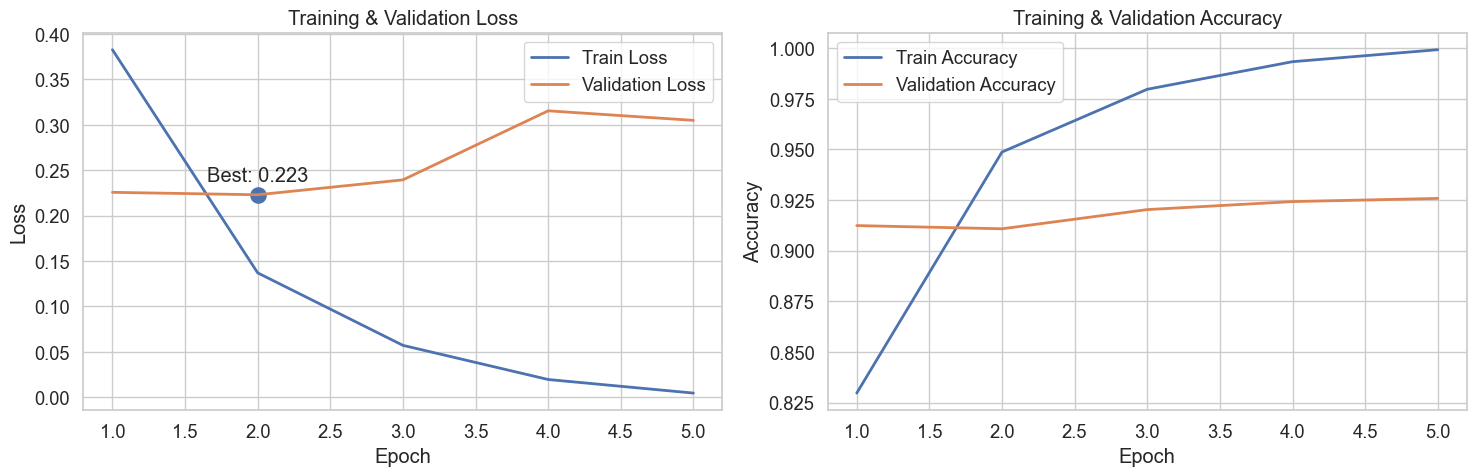

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid", font_scale=1.2)

def plot_history(history):
    epochs = range(1, len(history.history['loss']) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(15,5))

    # LOSS
    ax[0].plot(epochs, history.history['loss'], label='Train Loss', linewidth=2)
    ax[0].plot(epochs, history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax[0].set_title('Training & Validation Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()

    # Highlight best epoch
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_loss = min(history.history['val_loss'])
    ax[0].scatter(best_epoch, best_loss, s=120)
    ax[0].annotate(f'Best: {best_loss:.3f}',
                   (best_epoch, best_loss),
                   textcoords="offset points",
                   xytext=(0,10),
                   ha='center')

    # ACCURACY
    ax[1].plot(epochs, history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax[1].plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax[1].set_title('Training & Validation Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [9]:
from sklearn.metrics import classification_report

y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=le.classes_))

40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 396ms/step
              precision    recall  f1-score   support

        FAKE       0.90      0.92      0.91       633
        REAL       0.92      0.90      0.91       634

    accuracy                           0.91      1267
   macro avg       0.91      0.91      0.91      1267
weighted avg       0.91      0.91      0.91      1267

